In [30]:
import pandas as pd
import numpy as np

In [31]:
df = pd.read_csv("../data/raw/customer_booking.csv")
df.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe9 in position 14695: invalid continuation byte

In [ ]:
import os
os.getcwd()

In [32]:
df = pd.read_csv("data/raw/customer_booking.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/customer_booking.csv'

In [33]:
import pandas as pd
import numpy as np

In [34]:
df = pd.read_csv("data/raw/customer_booking.csv", encoding="latin-1")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/customer_booking.csv'

In [35]:
df = pd.read_csv("../data/raw/customer_booking.csv", encoding="latin-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [36]:
df.shape

(50000, 14)

In [37]:
df.columns

Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='str')

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


In [39]:
df.isna().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [40]:
df["booking_complete"].value_counts()

booking_complete
0    42522
1     7478
Name: count, dtype: int64

In [41]:
df["booking_complete"].value_counts(normalize=True) * 100

booking_complete
0    85.044
1    14.956
Name: proportion, dtype: float64

In [42]:
df.select_dtypes(include="object").nunique().sort_values(ascending=False)

C:\Users\user\AppData\Local\Temp\ipykernel_18420\1027885130.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").nunique().sort_values(ascending=False)


route             799
booking_origin    104
flight_day          7
trip_type           3
sales_channel       2
dtype: int64

In [43]:
#Target variable
y = df["booking_complete"]


#Feature matrix (drop the target)
X = df.drop(columns=["booking_complete"])

In [44]:
X.shape, y.shape

((50000, 13), (50000,))

In [45]:
#Numeric features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

#Categorical features
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features

C:\Users\user\AppData\Local\Temp\ipykernel_18420\1265933776.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


(['num_passengers',
  'purchase_lead',
  'length_of_stay',
  'flight_hour',
  'wants_extra_baggage',
  'wants_preferred_seat',
  'wants_in_flight_meals',
  'flight_duration'],
 ['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin'])

In [46]:
df = pd.read_csv("../data/raw/customer_booking.csv", encoding="latin-1")

In [47]:
categorical_features = [col for col in categorical_features if col != "route"]
categorical_features

['sales_channel', 'trip_type', 'flight_day', 'booking_origin']

In [48]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [49]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((40000, 13), (10000, 13))

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [52]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [53]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [54]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [55]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[8338,  166],
       [1334,  162]])

In [56]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.85

In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      8504
           1       0.49      0.11      0.18      1496

    accuracy                           0.85     10000
   macro avg       0.68      0.54      0.55     10000
weighted avg       0.81      0.85      0.81     10000



In [58]:
import pandas as pd

feature_importances = model.named_steps["classifier"].feature_importances_

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
    
}).sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
1,num__purchase_lead,0.226020
3,num__flight_hour,0.171416
2,num__length_of_stay,0.154411
7,num__flight_duration,0.097233
0,num__num_passengers,0.059086
70,cat__booking_origin_Malaysia,0.035525
6,num__wants_in_flight_meals,0.024323
24,cat__booking_origin_Australia,0.022749
4,num__wants_extra_baggage,0.018890
5,num__wants_preferred_seat,0.018733


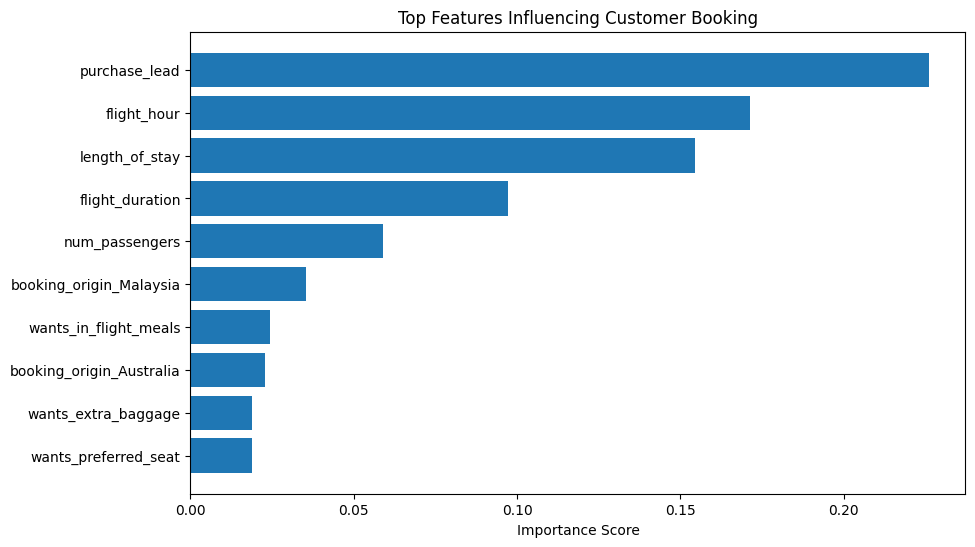

In [83]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features["feature"], top_features["importance"])

plt.gca().invert_yaxis()

plt.title("Top Features Influencing Customer Booking")

plt.xlabel("Importance Score")

plt.show
plt.savefig("../images/feature_importance.png", bbox_inches="tight")

In [60]:
importance_df["feature"] = importance_df["feature"].str.replace("num__", "")
importance_df["feature"] = importance_df["feature"].str.replace("cat__", "")

In [82]:
import joblib
joblib.dump(model, "../outputs/booking_model.pkl")

['../outputs/booking_model.pkl']